# U-Net Water Detection Training
**WorldView-2 and WorldView-3 | 16-bit 4-band (R,G,B,NIR1) | 512×512 chips | H100 NVL**
Using ImageNet pretrained ResNet34 encoder.

**NOTE: Do not re-run cells 1–3.** Scene split, normalisation stats, and test chip list are already saved to `results/unet_training/`. Re-running would reshuffle the split.

Run cells in order from cell 14 onwards if continuing from a fresh kernel.

In [1]:
# ── Cell 1: Imports and Configuration ──
import os, random, json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from collections import defaultdict
import rasterio
import segmentation_models_pytorch as smp
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Paths
BASE_DIR   = Path(os.environ.get(            # override via BASE_DIR env var
    'BASE_DIR',
    '/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask'
))
CHIPS_DIR  = BASE_DIR / 'images/chips_images/images'
MASKS_DIR  = BASE_DIR / 'images/chips_masks/masks'
OUTPUT_DIR = BASE_DIR / 'results/unet_training'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters
IN_CHANNELS   = 4      # R, G, B, NIR1 only (required for ImageNet pretraining)
BAND_INDICES  = [5, 3, 2, 7]   # rasterio 1-based band indices: R=5, G=3, B=2, NIR1=7
BATCH_SIZE    = 16
LR            = 1e-5
WEIGHT_DECAY  = 1e-4
MAX_EPOCHS    = 100
EARLY_STOP    = 10
VAL_SPLIT     = 0.20
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
if torch.cuda.is_available():
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB')
print(f'Chips: {len(list(CHIPS_DIR.glob("*.tif")))}')
print(f'Masks: {len(list(MASKS_DIR.glob("*.tif")))}')

Device: cuda
GPU: NVIDIA H100 NVL
VRAM: 100 GB
Chips: 17445
Masks: 17445


In [2]:
# ── Cell 2: Scene-level Split ──
# 13 scenes held out for testing (20% of 64 total scenes).
# Remaining 51 scenes split 80/20 into train/val at scene level.
# Only chips with >0% water are used for training.

TEST_SCENES = {
    '12AUG30193433_sub2', '15JUL02193_sub_2', '16Sep2219_1b_Chiwawa',
    '16Sep2219_1b_Teanaway', 'UGR_2017_08_30_103001007046C600_AOI_1',
    'UGR_2021_07_21_10300100C2972100_AOI_1', 'Wenatchee_2014_08_27_10300100354F7A00_AOI',
    'Wenatchee_2016_08_16_10400100214F5200_AOI_1', 'Wenatchee_2019_07_26_104001004E554F00_AOI_1',
    'Wenatchee_2022_11_09_104001007E867900_AOI_1', 'Wenatchee_2025_02_07_103001010D0A1600_AOI_1',
    'cath_creek_2015_10_09_10300100496A4600_AOI_1', 'cath_creek_2018_12_05_1040010046BF9000_AOI_1',
}

def get_scene_id(filename):
    name = Path(filename).stem
    if '_clipped_' in name: return name.split('_clipped_')[0]
    if '_clip_' in name:    return name.split('_clip_')[0]
    return name

all_chips  = sorted(CHIPS_DIR.glob('*.tif'))
mask_stems = {m.stem for m in MASKS_DIR.glob('*.tif')}

scene_to_chips = defaultdict(list)
for chip in all_chips:
    if chip.stem in mask_stems:
        scene_to_chips[get_scene_id(chip.name)].append(chip)

print(f'Total scenes: {len(scene_to_chips)}')
print(f'Total matched chips: {sum(len(v) for v in scene_to_chips.values())}')

test_chips    = []
trainval_scenes = {}
for sid, clist in scene_to_chips.items():
    if sid in TEST_SCENES:
        test_chips.extend(clist)
    else:
        trainval_scenes[sid] = clist

print(f'\nTest scenes: {len(TEST_SCENES)}, chips: {len(test_chips)}')
print(f'Train/val scenes: {len(trainval_scenes)}, chips: {sum(len(v) for v in trainval_scenes.values())}')

random.seed(SEED)
scene_list = sorted(trainval_scenes.keys())
random.shuffle(scene_list)
n_val = max(1, int(len(scene_list) * VAL_SPLIT))
val_scenes   = set(scene_list[:n_val])
train_scenes = set(scene_list[n_val:])

train_chips = [c for s in train_scenes for c in trainval_scenes[s]]
val_chips   = [c for s in val_scenes   for c in trainval_scenes[s]]

print(f'Train: {len(train_scenes)} scenes, {len(train_chips)} chips')
print(f'Val:   {len(val_scenes)} scenes, {len(val_chips)} chips')

# Filter training chips to those with ANY water pixels (>0%)
print(f'\nFiltering training chips to >0% water...')
kept = []
for c in tqdm(train_chips):
    with rasterio.open(MASKS_DIR / c.name) as src:
        if (src.read(1) > 0).any():
            kept.append(c)
train_chips = kept
print(f'Training chips after filter: {len(train_chips)}')

# Save test chip list
with open(OUTPUT_DIR / 'test_chips.json', 'w') as f:
    json.dump([c.name for c in test_chips], f)
print(f'\nTest chip list saved to {OUTPUT_DIR / "test_chips.json"}')

Total scenes: 64
Total matched chips: 17445

Test scenes: 13, chips: 4788
Train/val scenes: 51, chips: 12657
Train: 41 scenes, 9913 chips
Val:   10 scenes, 2744 chips

Filtering training chips to >0% water...


100%|██████████| 9913/9913 [24:22<00:00,  6.78it/s]


Training chips after filter: 2277

Test chip list saved to /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training/test_chips.json


In [3]:
# ── Cell 3: Normalisation Statistics ──
# Computed from TRAINING SET ONLY.
# Reads bands R(5), G(3), B(2), NIR1(7) matching IN_CHANNELS=4.
# Delete normalisation_stats.json if you changed IN_CHANNELS.

stats_path = OUTPUT_DIR / 'normalisation_stats.json'

if stats_path.exists():
    with open(stats_path) as f:
        stats = json.load(f)
    mean = np.array(stats['mean'], dtype=np.float32)
    std  = np.array(stats['std'],  dtype=np.float32)
    if len(mean) != IN_CHANNELS:
        print(f'WARNING: saved stats have {len(mean)} bands but IN_CHANNELS={IN_CHANNELS}')
        print('Delete normalisation_stats.json and rerun this cell.')
    else:
        print(f'Loaded normalisation stats from {stats_path}')
else:
    sample = random.sample(train_chips, min(500, len(train_chips)))
    sums, sq_sums, count = np.zeros(IN_CHANNELS), np.zeros(IN_CHANNELS), 0
    for chip in tqdm(sample, desc='Computing stats'):
        with rasterio.open(chip) as src:
            data = np.stack([src.read(b) for b in BAND_INDICES]).astype(np.float64)
        sums    += data.sum(axis=(1, 2))
        sq_sums += (data ** 2).sum(axis=(1, 2))
        count   += data.shape[1] * data.shape[2]
    mean = (sums / count).astype(np.float32)
    std  = np.sqrt(sq_sums / count - mean ** 2).astype(np.float32)
    std  = np.where(std < 1e-6, 1.0, std)
    with open(stats_path, 'w') as f:
        json.dump({'mean': mean.tolist(), 'std': std.tolist()}, f)
    print(f'Stats saved to {stats_path}')

print(f'Mean per band (R,G,B,NIR1): {[f"{m:.0f}" for m in mean]}')
print(f'Std per band  (R,G,B,NIR1): {[f"{s:.0f}" for s in std]}')

Loaded normalisation stats from /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training/normalisation_stats.json
Mean per band (R,G,B,NIR1): ['1144', '1162', '1188', '1329']
Std per band  (R,G,B,NIR1): ['8090', '8088', '8084', '8068']


## Model 1 — Single-Split Baseline
Configuration: ResNet34, ImageNet pretrained, 4 bands, pos_weight=10, LR=1e-5, 80/20 split, water chips only (2,277). Best val F1: 0.401 at epoch 11.

In [4]:
# ── Cell 4: Dataset with Augmentation ──
# Reads 4 bands: R(5), G(3), B(2), NIR1(7) — compatible with ImageNet pretraining.
# Augmentations applied to training only. Mask receives identical spatial transforms.

class WaterChipDataset(Dataset):
    def __init__(self, chip_paths, masks_dir, mean, std, augment=False):
        self.chip_paths = chip_paths
        self.masks_dir  = Path(masks_dir)
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std  = torch.tensor(std).view(-1, 1, 1)
        self.augment = augment

    def __len__(self):
        return len(self.chip_paths)

    def __getitem__(self, idx):
        cp = self.chip_paths[idx]
        mp = self.masks_dir / cp.name
        with rasterio.open(cp) as src:
            image = np.stack([src.read(b) for b in BAND_INDICES]).astype(np.float32)  # R,G,B,NIR1
        with rasterio.open(mp) as src:
            mask = (src.read(1) > 0).astype(np.float32)
        if self.augment:
            image, mask = self._augment(image, mask)
        image = (torch.from_numpy(image) - self.mean) / self.std
        return image, torch.from_numpy(mask).unsqueeze(0)

    def _augment(self, img, mask):
        if random.random() > 0.5:
            img = img[:, :, ::-1].copy(); mask = mask[:, ::-1].copy()
        if random.random() > 0.5:
            img = img[:, ::-1, :].copy(); mask = mask[::-1, :].copy()
        if random.random() > 0.25:
            k = random.choice([1, 2, 3])
            img  = np.rot90(img,  k, axes=(1, 2)).copy()
            mask = np.rot90(mask, k, axes=(0, 1)).copy()
        if random.random() > 0.5:
            for b in range(img.shape[0]):
                br = np.random.uniform(0.9, 1.1)
                ct = np.random.uniform(0.9, 1.1)
                mv = img[b].mean()
                img[b] = (img[b] - mv) * ct + mv * br
        return img, mask

train_ds = WaterChipDataset(train_chips, MASKS_DIR, mean, std, augment=True)
val_ds   = WaterChipDataset(val_chips,   MASKS_DIR, mean, std, augment=False)
print(f'Train dataset: {len(train_ds)} chips')
print(f'Val dataset:   {len(val_ds)} chips')

Train dataset: 2277 chips
Val dataset:   2744 chips


In [5]:
# ── Cell 5: Model, Loss, Optimiser ──
# U-Net + ResNet34 with ImageNet pretrained weights.
# in_channels=4: R, G, B, NIR1 — compatible with ImageNet pretraining.
# Dice + weighted BCE loss, pos_weight=10.

model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = 'imagenet',  # pretrained on 1.4M images — fast convergence
    in_channels     = IN_CHANNELS,  # 4 bands
    classes         = 1,
    activation      = None,
).to(DEVICE)

dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
bce_loss  = smp.losses.SoftBCEWithLogitsLoss(
    pos_weight=torch.tensor([10.0]).to(DEVICE)
)
def loss_fn(pred, target):
    return 0.5 * dice_loss(pred, target) + 0.5 * bce_loss(pred, target)

optimiser = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='max', patience=5, factor=0.5
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: U-Net + ResNet34 (ImageNet pretrained)')
print(f'Trainable parameters: {n_params:,}')
print(f'Device: {DEVICE}')

Model: U-Net + ResNet34 (ImageNet pretrained)
Trainable parameters: 24,439,505
Device: cuda


/anaconda/envs/owm/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [6]:
# ── Cell 6: WeightedRandomSampler + DataLoaders ──

print('Computing sample weights...')
weights = []
for cp in tqdm(train_chips):
    with rasterio.open(MASKS_DIR / cp.name) as src:
        wf = (src.read(1) > 0).mean()
    weights.append(max(float(wf), 1e-6))

sampler = WeightedRandomSampler(torch.tensor(weights), len(weights), replacement=True)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True
)
print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

Computing sample weights...


100%|██████████| 2277/2277 [05:30<00:00,  6.89it/s]

Train batches: 143
Val batches:   172


> **Note on the per-epoch F1 below.** `compute_metrics` evaluates F1/IoU/precision/recall **only on chips that contain water in the ground truth** (`water_mask = tb.sum(...) > 0`). These values are training diagnostics for monitoring convergence — they are **not** the reported results. The headline test metrics (best single fold and 5-fold ensemble, micro F1 on all 4,788 test chips) are produced in `unet_diagnostic_final.ipynb`.

In [7]:
# ── Cell 7: Training Loop ──

def compute_metrics(preds, targets, threshold=0.5):
    pb = (torch.sigmoid(preds) > threshold).cpu().numpy()
    tb = targets.cpu().numpy()
    # Only evaluate on chips that have water in ground truth
    water_mask = tb.sum(axis=(1,2,3)) > 0
    if water_mask.sum() == 0:
        return {'f1': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0}
    pb = pb[water_mask].flatten().astype(int)
    tb = tb[water_mask].flatten().astype(int)
    return {
        'f1':        round(f1_score(tb, pb, zero_division=0), 4),
        'iou':       round(jaccard_score(tb, pb, zero_division=0), 4),
        'precision': round(precision_score(tb, pb, zero_division=0), 4),
        'recall':    round(recall_score(tb, pb, zero_division=0), 4),
    }

best_val_f1, no_improve, history = 0.0, 0, []

for epoch in range(1, MAX_EPOCHS + 1):
    # Train
    model.train()
    t_losses, t_p, t_t = [], [], []
    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch} train', leave=False):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimiser.zero_grad()
        out  = model(imgs)
        loss = loss_fn(out, masks)
        loss.backward()
        optimiser.step()
        t_losses.append(loss.item())
        t_p.append(out.detach()); t_t.append(masks.detach())
    tm = compute_metrics(torch.cat(t_p), torch.cat(t_t))

    # Validate
    model.eval()
    v_losses, v_p, v_t = [], [], []
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f'Epoch {epoch} val', leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            out = model(imgs)
            v_losses.append(loss_fn(out, masks).item())
            v_p.append(out); v_t.append(masks)
    vm = compute_metrics(torch.cat(v_p), torch.cat(v_t))
    scheduler.step(vm['f1'])

    row = {
        'epoch': epoch, 'train_loss': round(np.mean(t_losses), 4),
        'val_loss': round(np.mean(v_losses), 4),
        'train_f1': round(tm['f1'], 4), 'val_f1': round(vm['f1'], 4),
        'val_iou': round(vm['iou'], 4), 'val_prec': round(vm['precision'], 4),
        'val_rec': round(vm['recall'], 4), 'lr': optimiser.param_groups[0]['lr'],
    }
    history.append(row)
    print(f"Ep {epoch:3d} | Loss {np.mean(t_losses):.4f}/{np.mean(v_losses):.4f} | "
          f"F1 {tm['f1']:.4f}/{vm['f1']:.4f} | IoU {vm['iou']:.4f} | "
          f"P {vm['precision']:.4f} | R {vm['recall']:.4f}")

    if vm['f1'] > best_val_f1:
        best_val_f1 = vm['f1']
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')
        print(f'  ✓ New best val F1: {best_val_f1:.4f} — model saved')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP:
            print(f'Early stopping at epoch {epoch}')
            break

df_hist = pd.DataFrame(history)
df_hist.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
print(f'\nBest val F1: {best_val_f1:.4f}')
print(f'Best model saved to: {OUTPUT_DIR / "best_model.pth"}')

Epoch 1 train:   0%|          | 0/143 [00:00<?, ?it/s]/anaconda/envs/owm/lib/python3.12/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
                                                                

Ep   1 | Loss 1.1100/1.2295 | F1 0.5878/0.0984 | IoU 0.0517 | P 0.0520 | R 0.9185
  ✓ New best val F1: 0.0984 — model saved


Ep   2 | Loss 0.6891/0.8999 | F1 0.7489/0.1288 | IoU 0.0689 | P 0.0711 | R 0.6826
  ✓ New best val F1: 0.1288 — model saved


Ep   3 | Loss 0.5512/0.6603 | F1 0.7923/0.1715 | IoU 0.0938 | P 0.1166 | R 0.3238
  ✓ New best val F1: 0.1715 — model saved


Ep   4 | Loss 0.4886/0.6070 | F1 0.8201/0.2380 | IoU 0.1351 | P 0.2291 | R 0.2477
  ✓ New best val F1: 0.2380 — model saved


...

Ep  17 | Loss 0.2463/0.5361 | F1 0.9221/0.2725 | IoU 0.1577 | P 0.7614 | R 0.1659


Ep  18 | Loss 0.2446/0.5261 | F1 0.9217/0.3671 | IoU 0.2248 | P 0.7763 | R 0.2404


Ep  19 | Loss 0.2410/0.5407 | F1 0.9232/0.3550 | IoU 0.2158 | P 0.4953 | R 0.2766


Ep  20 | Loss 0.2366/0.5356 | F1 0.9231/0.3297 | IoU 0.1974 | P 0.7889 | R 0.2084


Ep  21 | Loss 0.2317/0.5317 | F1 0.9281/0.3715 | IoU 0.2281 | P 0.4774 | R 0.3041
Early stopping at epoch 21

Best val F1: 0.4012
Best model saved to: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training/best_model.pth


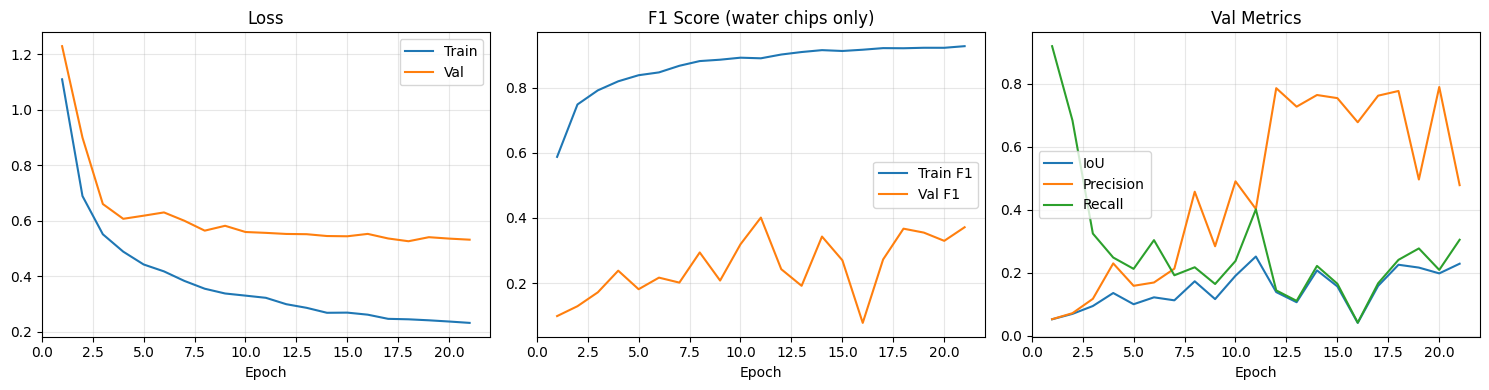

Saved to /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training/training_curves.png


In [8]:
# ── Cell 8: Training Curves ──

df_hist = pd.read_csv(OUTPUT_DIR / 'training_history.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df_hist['epoch'], df_hist['train_loss'], label='Train')
axes[0].plot(df_hist['epoch'], df_hist['val_loss'],   label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_hist['epoch'], df_hist['train_f1'], label='Train F1')
axes[1].plot(df_hist['epoch'], df_hist['val_f1'],   label='Val F1')
axes[1].set_xlabel('Epoch'); axes[1].set_title('F1 (diagnostic, water chips only)')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(df_hist['epoch'], df_hist['val_iou'],  label='IoU')
axes[2].plot(df_hist['epoch'], df_hist['val_prec'], label='Precision')
axes[2].plot(df_hist['epoch'], df_hist['val_rec'],  label='Recall')
axes[2].set_xlabel('Epoch'); axes[2].set_title('Val Metrics')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {OUTPUT_DIR / "training_curves.png"}')

## Model 2 — 5-Fold Cross-Validation
Same configuration as Model 1 but with 5-fold k-fold (90/10 split). Best val F1: 0.753 (fold 3, epoch 26). Oscillation pattern persisted due to LR too high for stable convergence with ReduceLROnPlateau.

In [ ]:
# ── Cell 9: K-Fold Training Loop ──
from sklearn.model_selection import KFold

scene_list = sorted(trainval_scenes.keys())
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

fold_results = []
best_overall_f1 = 0.0

for fold, (train_idx, val_idx) in enumerate(kf.split(scene_list)):
    print(f'\n{"="*60}')
    print(f'FOLD {fold+1}/5')
    print(f'{"="*60}')

    train_scenes_fold = [scene_list[i] for i in train_idx]
    val_scenes_fold   = [scene_list[i] for i in val_idx]

    # Get chips
    all_train = [c for s in train_scenes_fold for c in trainval_scenes[s]]
    val_chips  = [c for s in val_scenes_fold   for c in trainval_scenes[s]]

    # Filter training to >0% water
    print(f'Filtering training chips to >0% water...')
    train_chips = []
    for c in tqdm(all_train, leave=False):
        with rasterio.open(MASKS_DIR / c.name) as src:
            if (src.read(1) > 0).any():
                train_chips.append(c)
    print(f'Train: {len(train_chips)} water chips / {len(all_train)} total')
    print(f'Val:   {len(val_chips)} chips')

    # Datasets
    train_ds = WaterChipDataset(train_chips, MASKS_DIR, mean, std, augment=True)
    val_ds   = WaterChipDataset(val_chips,   MASKS_DIR, mean, std, augment=False)

    # WeightedRandomSampler
    weights = []
    for cp in train_chips:
        with rasterio.open(MASKS_DIR / cp.name) as src:
            wf = (src.read(1) > 0).mean()
        weights.append(max(float(wf), 1e-6))
    sampler = WeightedRandomSampler(torch.tensor(weights), len(weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True)

    # Fresh model + optimiser per fold
    model     = smp.Unet(
        encoder_name='resnet34', encoder_weights='imagenet',
        in_channels=IN_CHANNELS, classes=1, activation=None,
    ).to(DEVICE)
    optimiser = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='max', patience=5, factor=0.5
    )

    best_val_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, MAX_EPOCHS+1):
        # Train
        model.train()
        t_losses, t_p, t_t = [], [], []
        for imgs, masks in tqdm(train_loader, desc=f'F{fold+1} E{epoch} train', leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimiser.zero_grad()
            out  = model(imgs)
            loss = loss_fn(out, masks)
            loss.backward()
            optimiser.step()
            t_losses.append(loss.item())
            t_p.append(out.detach()); t_t.append(masks.detach())
        tm = compute_metrics(torch.cat(t_p), torch.cat(t_t))

        # Validate
        model.eval()
        v_losses, v_p, v_t = [], [], []
        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, desc=f'F{fold+1} E{epoch} val', leave=False):
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                out = model(imgs)
                v_losses.append(loss_fn(out, masks).item())
                v_p.append(out); v_t.append(masks)
        vm = compute_metrics(torch.cat(v_p), torch.cat(v_t))
        scheduler.step(vm['f1'])

        row = {
            'fold': fold+1, 'epoch': epoch,
            'train_loss': round(np.mean(t_losses), 4),
            'val_loss':   round(np.mean(v_losses), 4),
            'train_f1':   round(tm['f1'], 4),
            'val_f1':     round(vm['f1'], 4),
            'val_iou':    round(vm['iou'], 4),
            'val_prec':   round(vm['precision'], 4),
            'val_rec':    round(vm['recall'], 4),
            'lr':         optimiser.param_groups[0]['lr'],
        }
        history.append(row)
        print(f"F{fold+1} Ep {epoch:3d} | Loss {np.mean(t_losses):.4f}/{np.mean(v_losses):.4f} | "
              f"F1 {tm['f1']:.4f}/{vm['f1']:.4f} | IoU {vm['iou']:.4f} | "
              f"P {vm['precision']:.4f} | R {vm['recall']:.4f}")

        if vm['f1'] > best_val_f1:
            best_val_f1 = vm['f1']
            torch.save(model.state_dict(), OUTPUT_DIR / f'best_model_fold{fold+1}.pth')
            if vm['f1'] > best_overall_f1:
                best_overall_f1 = vm['f1']
                torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')
                print(f'  ✓ New best overall val F1: {best_overall_f1:.4f} — best_model.pth saved')
            else:
                print(f'  ✓ New best fold {fold+1} val F1: {best_val_f1:.4f}')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= EARLY_STOP:
                print(f'  Early stopping fold {fold+1} at epoch {epoch}')
                break

    fold_results.append({
        'fold': fold+1, 'best_val_f1': best_val_f1,
        'train_scenes': len(train_scenes_fold),
        'val_scenes': len(val_scenes_fold)
    })
    pd.DataFrame(history).to_csv(OUTPUT_DIR / f'history_fold{fold+1}.csv', index=False)
    print(f'Fold {fold+1} complete — best val F1: {best_val_f1:.4f}')

print(f'\n{"="*60}')
print(f'K-FOLD COMPLETE')
print(f'{"="*60}')
for r in fold_results:
    print(f'  Fold {r["fold"]}: val F1 = {r["best_val_f1"]:.4f} ({r["train_scenes"]} train / {r["val_scenes"]} val scenes)')
print(f'\nBest overall val F1: {best_overall_f1:.4f}')
print(f'Best model saved to: {OUTPUT_DIR / "best_model.pth"}')
pd.DataFrame(fold_results).to_csv(OUTPUT_DIR / 'kfold_summary.csv', index=False)


FOLD 1/5
Filtering training chips to >0% water...


Train: 1977 water chips / 10163 total
Val:   2494 chips


F1 E1 train:  98%|█████████▊| 122/124 [02:45<00:03,  1.55s/it]/anaconda/envs/owm/lib/python3.12/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
                                                              

F1 Ep   1 | Loss 1.0509/1.3870 | F1 0.4674/0.2660 | IoU 0.1534 | P 0.1557 | R 0.9131
  ✓ New best overall val F1: 0.2660 — best_model.pth saved


F1 Ep   2 | Loss 0.6864/0.9508 | F1 0.6660/0.3816 | IoU 0.2358 | P 0.2550 | R 0.7581
  ✓ New best overall val F1: 0.3816 — best_model.pth saved


...

F5 Ep   7 | Loss 0.3779/0.6540 | F1 0.8722/0.4495 | IoU 0.2899 | P 0.4063 | R 0.5030
  ✓ New best fold 5 val F1: 0.4495


F5 Ep   8 | Loss 0.3532/0.6610 | F1 0.8839/0.4277 | IoU 0.2720 | P 0.3607 | R 0.5252


F5 Ep   9 | Loss 0.3441/0.6407 | F1 0.8880/0.5521 | IoU 0.3813 | P 0.4561 | R 0.6993
  ✓ New best fold 5 val F1: 0.5521


F5 Ep  10 | Loss 0.3269/0.6330 | F1 0.8926/0.5566 | IoU 0.3857 | P 0.4431 | R 0.7484
  ✓ New best fold 5 val F1: 0.5566


F5 E11 train:  36%|███▋      | 53/146 [01:15<02:27,  1.58s/it]

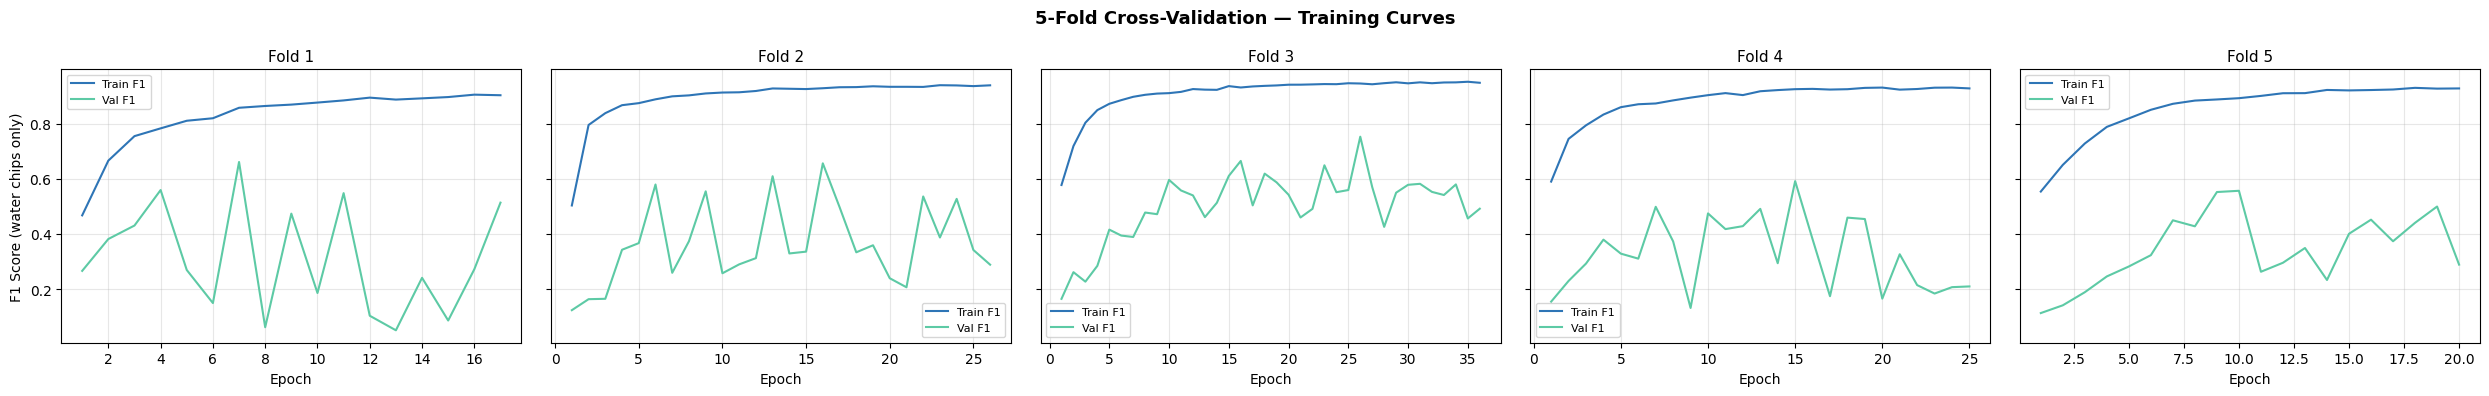

Saved to /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training/kfold_curves.png


In [2]:
# ── Cell 10: K-Fold Training Curves ──

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training')

fig, axes = plt.subplots(1, 5, figsize=(25, 4), sharey=True)

for fold in range(1, 6):
    csv_path = OUTPUT_DIR / f'history_fold{fold}.csv'
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    ax = axes[fold-1]
    ax.plot(df['epoch'], df['train_f1'], label='Train F1', color='#2E75B6')
    ax.plot(df['epoch'], df['val_f1'],   label='Val F1',   color='#5DCAA5')
    ax.set_title(f'Fold {fold}', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

axes[0].set_ylabel('F1 Score (water chips only)')
plt.suptitle('5-Fold Cross-Validation — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kfold_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {OUTPUT_DIR / "kfold_curves.png"}')

## Model 3 — Improved Configuration
**Key changes:** LR=1e-4 + warm-up cosine scheduler, WD=1e-3, gradient clipping (max_norm=1.0), Focal+Dice loss (selected by two-round sweep), 80/20 train/val split at scene level, on-the-fly augmentation (V3 suite — original chips only, no pre-generated dataset).

**Note:** an offline pre-generated augmented dataset (~20,100 chips) was tried first but caused the model to collapse on validation (Val F1 stuck at 0.000 after epoch 1, despite Train F1 climbing past 0.80). Switched to on-the-fly augmentation per supervisor's original recommendation — this avoids overfitting to a fixed set of heavily augmented images and exposes the model to infinite variety each epoch.

**Training set:** all water chips (2,680) + 20% land sample (~670), originals only. **Validation:** all original chips from val scenes, unmodified.

**Run order:** Cell 11 (defines `WaterChipDatasetV3`) → Cell 12 (two-round hyperparameter sweep) → Cell 13 (full k-fold) → Cell 14 (restart folds 4+5 if needed)

In [2]:
# ── Cell 11: WaterChipDatasetV3 — On-the-Fly Augmentation (FINAL) ──
# Loads from ORIGINAL chips only (chips_images/images/).
# Applies V3 augmentation suite randomly each time a chip is loaded.
# No pre-generated dataset needed — variety comes from random augmentation every epoch.
# Used by cell 12 (sweep), cell 13 (k-fold), cell 14 (restart), and cell 16 (final model)

import torch, random, cv2
import numpy as np
import rasterio
from pathlib import Path
from torch.utils.data import Dataset

class WaterChipDatasetV3(Dataset):
    def __init__(self, chip_paths, masks_dir, mean, std, augment=False):
        self.chip_paths = chip_paths
        self.masks_dir  = Path(masks_dir)
        self.mean = torch.tensor(mean).view(-1,1,1)
        self.std  = torch.tensor(std).view(-1,1,1)
        self.augment = augment

    def __len__(self): return len(self.chip_paths)

    def __getitem__(self, idx):
        cp = self.chip_paths[idx]
        mp = self.masks_dir / cp.name
        with rasterio.open(cp) as src:
            image = np.stack([src.read(b) for b in BAND_INDICES]).astype(np.float32)  # R,G,B,NIR1
        with rasterio.open(mp) as src:
            mask = (src.read(1) > 0).astype(np.float32)

        if self.augment:
            image, mask = self._augment(image, mask)

        image = (torch.from_numpy(image) - self.mean) / self.std
        return image, torch.from_numpy(mask.copy()).unsqueeze(0)

    def _augment(self, img, mask):
        # ── Spatial — applied to image AND mask ──
        if random.random() > 0.5:
            img  = img[:, :, ::-1].copy()
            mask = mask[:, ::-1].copy()
        if random.random() > 0.5:
            img  = img[:, ::-1, :].copy()
            mask = mask[::-1, :].copy()
        if random.random() > 0.25:
            k    = random.choice([1, 2, 3])
            img  = np.rot90(img,  k, axes=(1, 2)).copy()
            mask = np.rot90(mask, k, axes=(0, 1)).copy()
        if random.random() > 0.5:
            h, w      = img.shape[1], img.shape[2]
            crop_size = random.randint(int(h * 0.7), h)
            row       = random.randint(0, h - crop_size)
            col       = random.randint(0, w - crop_size)
            img       = img[:, row:row+crop_size, col:col+crop_size]
            mask      = mask[row:row+crop_size, col:col+crop_size]
            img  = np.stack([cv2.resize(img[b], (w, h), interpolation=cv2.INTER_LINEAR) for b in range(img.shape[0])])
            mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        # ── Radiometric — image only ──
        if random.random() > 0.5:
            for b in range(img.shape[0]):
                br = np.random.uniform(0.8, 1.2)
                ct = np.random.uniform(0.8, 1.2)
                mv = img[b].mean()
                img[b] = (img[b] - mv) * ct + mv * br
        if random.random() > 0.5:
            for b in range(img.shape[0]):
                noise_std = np.random.uniform(0.005, 0.03) * img[b].std()
                img[b]    = img[b] + np.random.normal(0, noise_std, img[b].shape).astype(np.float32)

        # ── Band-specific ──
        if random.random() > 0.7:
            img[random.randint(0, img.shape[0] - 1)] = 0.0

        # ── Terrain ──
        if random.random() > 0.7:
            h, w   = img.shape[1], img.shape[2]
            sh     = random.randint(h // 8, h // 3)
            sw     = random.randint(w // 8, w // 3)
            sr     = random.randint(0, h - sh)
            sc     = random.randint(0, w - sw)
            img[:, sr:sr+sh, sc:sc+sw] *= np.random.uniform(0.3, 0.7)
        if random.random() > 0.8:
            h, w   = img.shape[1], img.shape[2]
            gh     = random.randint(h // 16, h // 6)
            gw     = random.randint(w // 16, w // 6)
            gr     = random.randint(0, h - gh)
            gc     = random.randint(0, w - gw)
            img[:, gr:gr+gh, gc:gc+gw] *= np.random.uniform(1.3, 2.0)

        img = np.clip(img, 0, img.max() if img.max() > 0 else 1)
        return img, mask

print('WaterChipDatasetV3 defined — ON-THE-FLY augmentation')
print('Loads from original chips only (no pre-generated dataset)')
print('Augmentations applied randomly each time a chip is loaded')

WaterChipDatasetV3 defined — ON-THE-FLY augmentation
Loads from original chips only (no pre-generated dataset)
Augmentations applied randomly each time a chip is loaded


In [4]:
# ── Cell 12: Final Two-Round Hyperparameter Sweep — Model 3 ──
#
# Fixed baseline (from stability investigation):
#   BS=64, WD=1e-3, gradient clipping (max_norm=1.0), warm-up=3 epochs
#   On-the-fly augmentation (original V3 suite)
#
# Round 1 (C1, C2, C3): Find best loss function (LR=4e-4 fixed)
#   C1: Tversky (alpha=0.3, beta=0.7) — best performing in stability tests
#   C2: Dice — baseline comparison
#   C3: Focal+Dice — combined loss
#
# Round 2 (C4, C5, C6): Test LR using best loss from Round 1
#   C4: LR=2e-4 (lower than stability test)
#   C5: LR=4e-4 (same as stability test — confirmed good)
#   C6: LR=6e-4 (slightly higher)
#
# Results saved to: results/unet_training_v3/sweep_final/

import segmentation_models_pytorch as smp
import torch, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import KFold
from collections import defaultdict
from tqdm import tqdm
import rasterio

BASE_DIR   = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
CHIPS_DIR  = BASE_DIR / 'images/chips_images/images'
MASKS_DIR  = BASE_DIR / 'images/chips_masks/masks'
OUTPUT_DIR = BASE_DIR / 'results/unet_training_v3/sweep_final'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IN_CHANNELS   = 4
MAX_EPOCHS    = 100
PATIENCE      = 15
SEED          = 42
N_FOLDS       = 5
LAND_PCT      = 0.20
WARMUP_EPOCHS = 3
BATCH_SIZE    = 64
GRAD_CLIP     = 1.0

random.seed(SEED)
np.random.seed(SEED)

with open(BASE_DIR / 'results/unet_training/normalisation_stats.json') as f:
    stats = json.load(f)
mean = np.array(stats['mean'], dtype=np.float32)
std  = np.array(stats['std'],  dtype=np.float32)

TEST_SCENES = {
    '12AUG30193433_sub2', '15JUL02193_sub_2', '16Sep2219_1b_Chiwawa',
    '16Sep2219_1b_Teanaway', 'UGR_2017_08_30_103001007046C600_AOI_1',
    'UGR_2021_07_21_10300100C2972100_AOI_1', 'Wenatchee_2014_08_27_10300100354F7A00_AOI',
    'Wenatchee_2016_08_16_10400100214F5200_AOI_1', 'Wenatchee_2019_07_26_104001004E554F00_AOI_1',
    'Wenatchee_2022_11_09_104001007E867900_AOI_1', 'Wenatchee_2025_02_07_103001010D0A1600_AOI_1',
    'cath_creek_2015_10_09_10300100496A4600_AOI_1', 'cath_creek_2018_12_05_1040010046BF9000_AOI_1',
}

def get_scene_id(filename):
    name = Path(filename).stem
    if '_clipped_' in name: return name.split('_clipped_')[0]
    if '_clip_' in name:    return name.split('_clip_')[0]
    return name

all_chips  = sorted(CHIPS_DIR.glob('*.tif'))
mask_stems = {m.stem for m in MASKS_DIR.glob('*.tif')}

scene_to_water = defaultdict(list)
scene_to_land  = defaultdict(list)

for chip in all_chips:
    if chip.stem not in mask_stems: continue
    sid = get_scene_id(chip.name)
    if sid in TEST_SCENES: continue
    with rasterio.open(MASKS_DIR / chip.name) as src:
        has_water = (src.read(1) > 0).any()
    if has_water:
        scene_to_water[sid].append(chip)
    else:
        scene_to_land[sid].append(chip)

scene_list = sorted(set(scene_to_water.keys()) | set(scene_to_land.keys()))
random.shuffle(scene_list)

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold1_train_idx, fold1_val_idx = next(iter(kf.split(scene_list)))
train_scenes = set(scene_list[i] for i in fold1_train_idx)
val_scenes   = set(scene_list[i] for i in fold1_val_idx)

print(f'Train scenes: {len(train_scenes)}, Val scenes: {len(val_scenes)}')

train_water    = [c for s in train_scenes for c in scene_to_water.get(s, [])]
train_land_all = [c for s in train_scenes for c in scene_to_land.get(s, [])]
n_land         = round(len(train_water) * LAND_PCT / (1 - LAND_PCT))
n_land         = min(n_land, len(train_land_all))
train_land     = random.sample(train_land_all, n_land)
train_chips    = train_water + train_land
val_chips      = [c for s in val_scenes for c in (scene_to_water.get(s, []) + scene_to_land.get(s, []))]

print(f'Train chips: {len(train_chips):,} (water={len(train_water):,}, land={len(train_land):,})')
print(f'Val chips:   {len(val_chips):,}')

# ── Loss functions ──
def get_loss_fn(loss_name):
    dice = smp.losses.DiceLoss(mode='binary', from_logits=True, smooth=1.0)
    if loss_name == 'dice':
        return lambda p, t: dice(p, t)
    elif loss_name == 'tversky':
        tversky = smp.losses.TverskyLoss(mode='binary', from_logits=True, alpha=0.3, beta=0.7, smooth=1.0)
        return lambda p, t: tversky(p, t)
    elif loss_name == 'focal_dice':
        focal = smp.losses.FocalLoss(mode='binary')
        return lambda p, t: 0.5 * dice(p, t) + 0.5 * focal(p, t)

# ── Metrics ──
def compute_metrics(preds, targets, threshold=0.3):
    pb = (torch.sigmoid(preds) > threshold).cpu().numpy()
    tb = targets.cpu().numpy()
    water_mask = tb.sum(axis=(1,2,3)) > 0
    if water_mask.sum() == 0:
        return {'f1': 0.0, 'precision': 0.0, 'recall': 0.0}
    pb = pb[water_mask].flatten().astype(int)
    tb = tb[water_mask].flatten().astype(int)
    return {
        'f1':        round(f1_score(tb, pb, zero_division=0), 4),
        'precision': round(precision_score(tb, pb, zero_division=0), 4),
        'recall':    round(recall_score(tb, pb, zero_division=0), 4),
    }

# ── LR scheduler ──
def make_warmup_cosine_scheduler(optimiser, warmup_epochs, max_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return 0.1 + 0.9 * (epoch / warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, (max_epochs - warmup_epochs))
        return 0.5 * (1 + np.cos(np.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimiser, lr_lambda)

# ── Training function ──
def train_config(cfg):
    print(f'\n{"="*60}')
    print(f'Config: {cfg["name"]}')
    print(f'  LR={cfg["lr"]}, WD={1e-3}, Loss={cfg["loss"]}, BS={BATCH_SIZE}, gradclip={GRAD_CLIP}')
    print(f'{"="*60}')

    train_ds = WaterChipDatasetV3(train_chips, MASKS_DIR, mean, std, augment=True)
    val_ds   = WaterChipDatasetV3(val_chips,   MASKS_DIR, mean, std, augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True)

    model = smp.Unet(
        encoder_name='resnet34', encoder_weights='imagenet',
        in_channels=IN_CHANNELS, classes=1, activation=None,
    ).to(DEVICE)

    loss_fn   = get_loss_fn(cfg['loss'])
    optimiser = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=1e-3)
    scheduler = make_warmup_cosine_scheduler(optimiser, WARMUP_EPOCHS, MAX_EPOCHS)

    best_val_loss = float('inf')
    no_improve    = 0
    history       = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        t_losses, t_preds, t_targets = [], [], []
        for imgs, masks in tqdm(train_loader, desc=f'{cfg["name"]} E{epoch} train', leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimiser.zero_grad()
            out  = model(imgs)
            loss = loss_fn(out, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
            optimiser.step()
            t_losses.append(loss.item())
            t_preds.append(out.detach().cpu())
            t_targets.append(masks.detach().cpu())
        scheduler.step()
        current_lr = optimiser.param_groups[0]['lr']
        tm = compute_metrics(torch.cat(t_preds), torch.cat(t_targets))
        del t_preds, t_targets

        model.eval()
        v_losses, v_preds, v_targets = [], [], []
        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, desc=f'{cfg["name"]} E{epoch} val', leave=False):
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                out = model(imgs)
                v_losses.append(loss_fn(out, masks).item())
                v_preds.append(out.cpu())
                v_targets.append(masks.cpu())
        vm = compute_metrics(torch.cat(v_preds), torch.cat(v_targets))
        del v_preds, v_targets

        t_loss = round(np.mean(t_losses), 4)
        v_loss = round(np.mean(v_losses), 4)

        history.append({
            'epoch': epoch, 'lr': round(current_lr, 6),
            'train_loss': t_loss, 'val_loss': v_loss,
            'train_f1': tm['f1'], 'val_f1': vm['f1'],
            'val_prec': vm['precision'], 'val_rec': vm['recall'],
        })

        print(f"E{epoch:3d} | LR: {current_lr:.6f} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | "
              f"Train F1: {tm['f1']:.4f} | Val F1: {vm['f1']:.4f} | "
              f"P: {vm['precision']:.4f} | R: {vm['recall']:.4f}")

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), OUTPUT_DIR / f'{cfg["name"]}_best.pth')
            print(f'  ✓ New best val loss: {best_val_loss:.4f} — model saved')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUTPUT_DIR / f'{cfg["name"]}_history.csv', index=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss', color='#2E75B6')
    axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val Loss',   color='#E8A838')
    axes[0].set_title(f'{cfg["name"]} — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(hist_df['epoch'], hist_df['train_f1'], label='Train F1', color='#2E75B6')
    axes[1].plot(hist_df['epoch'], hist_df['val_f1'],   label='Val F1',   color='#5DCAA5')
    axes[1].set_title(f'{cfg["name"]} — F1'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle(cfg['name'], fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{cfg["name"]}_curves.png', dpi=150, bbox_inches='tight')
    plt.close()

    return {
        'config': cfg['name'], 'lr': cfg['lr'], 'loss': cfg['loss'],
        'best_val_loss': best_val_loss, 'best_val_f1': hist_df['val_f1'].max(),
    }

# ════════════════════════════════════════════════════════════
# ROUND 1 — Loss function (LR=4e-4 fixed)
# ════════════════════════════════════════════════════════════
print('\n' + '█'*60)
print('ROUND 1 — Loss function comparison (LR=4e-4, BS=64, WD=1e-3, gradclip)')
print('█'*60)

CONFIGS_R1 = [
    {'name': 'C1_tversky', 'lr': 4e-4, 'loss': 'tversky'},
    {'name': 'C2_dice',    'lr': 4e-4, 'loss': 'dice'},
    {'name': 'C3_focal_dice', 'lr': 4e-4, 'loss': 'focal_dice'},
]

r1_results = [train_config(cfg) for cfg in CONFIGS_R1]
r1_df = pd.DataFrame(r1_results).sort_values('best_val_loss')
r1_df.to_csv(OUTPUT_DIR / 'round1_summary.csv', index=False)

print(f'\n{"="*60}')
print('ROUND 1 RESULTS:')
print(f'{"="*60}')
print(r1_df[['config','loss','best_val_loss','best_val_f1']].to_string(index=False))

best_loss = r1_df.iloc[0]['loss']
print(f'\n✓ Best loss: {best_loss}')

# ════════════════════════════════════════════════════════════
# ROUND 2 — LR comparison (best loss fixed)
# ════════════════════════════════════════════════════════════
print('\n' + '█'*60)
print(f'ROUND 2 — LR comparison (loss={best_loss}, BS=64, WD=1e-3, gradclip)')
print('█'*60)

CONFIGS_R2 = [
    {'name': f'C4_lr2e4_{best_loss}', 'lr': 2e-4, 'loss': best_loss},
    {'name': f'C5_lr4e4_{best_loss}', 'lr': 4e-4, 'loss': best_loss},
    {'name': f'C6_lr6e4_{best_loss}', 'lr': 6e-4, 'loss': best_loss},
]

r2_results = [train_config(cfg) for cfg in CONFIGS_R2]
r2_df = pd.DataFrame(r2_results).sort_values('best_val_loss')
r2_df.to_csv(OUTPUT_DIR / 'round2_summary.csv', index=False)

print(f'\n{"="*60}')
print('ROUND 2 RESULTS:')
print(f'{"="*60}')
print(r2_df[['config','lr','loss','best_val_loss','best_val_f1']].to_string(index=False))

# ════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════
all_df = pd.DataFrame(r1_results + r2_results).sort_values('best_val_loss')
all_df.to_csv(OUTPUT_DIR / 'sweep_summary.csv', index=False)

best = all_df.iloc[0]
print(f'\n{"="*60}')
print('SWEEP COMPLETE — Best overall config:')
print(f'{"="*60}')
print(f'  Config:    {best["config"]}')
print(f'  LR:        {best["lr"]}')
print(f'  Loss:      {best["loss"]}')
print(f'  Val loss:  {best["best_val_loss"]:.4f}')
print(f'  Val F1:    {best["best_val_f1"]:.4f}')
print(f'\nFixed settings: BS=64, WD=1e-3, gradient clipping (max_norm=1.0), warm-up=3 epochs')
print(f'Run Cell 13 (full k-fold) with best config above.')

Train scenes: 40, Val scenes: 11
Train chips: 2,606 (water=2,085, land=521)
Val chips:   2,514

████████████████████████████████████████████████████████████
ROUND 1 — Loss function comparison (LR=4e-4, BS=64, WD=1e-3, gradclip)
████████████████████████████████████████████████████████████

Config: C1_tversky
  LR=0.0004, WD=64, Loss=tversky, BS=64, gradclip=1.0


C1_tversky E1 train:  98%|█████████▊| 40/41 [03:34<00:03,  3.00s/it]/anaconda/envs/owm/lib/python3.12/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
                                                                    

E  1 | LR: 0.000160 | Train Loss: 0.7724 | Val Loss: 0.4520 | Train F1: 0.1882 | Val F1: 0.1848 | P: 0.1022 | R: 0.9647
  ✓ New best val loss: 0.4520 — model saved


E  2 | LR: 0.000280 | Train Loss: 0.6312 | Val Loss: 0.4433 | Train F1: 0.3071 | Val F1: 0.4212 | P: 0.3316 | R: 0.5772
  ✓ New best val loss: 0.4433 — model saved


E  3 | LR: 0.000400 | Train Loss: 0.5182 | Val Loss: 0.3730 | Train F1: 0.6084 | Val F1: 0.5752 | P: 0.4317 | R: 0.8618
  ✓ New best val loss: 0.3730 — model saved


...

E 61 | LR: 0.000209 | Train Loss: 0.0746 | Val Loss: 0.0944 | Train F1: 0.9053 | Val F1: 0.8450 | P: 0.8859 | R: 0.8077


E 62 | LR: 0.000200 | Train Loss: 0.0711 | Val Loss: 0.0920 | Train F1: 0.9096 | Val F1: 0.8650 | P: 0.9211 | R: 0.8154


E 63 | LR: 0.000191 | Train Loss: 0.0730 | Val Loss: 0.1150 | Train F1: 0.9080 | Val F1: 0.8280 | P: 0.8899 | R: 0.7741


E 64 | LR: 0.000182 | Train Loss: 0.0782 | Val Loss: 0.0996 | Train F1: 0.9006 | Val F1: 0.8568 | P: 0.9186 | R: 0.8028


KeyboardInterrupt: 

In [ ]:
# ── Cell 13: Full 5-Fold K-Fold Cross-Validation — Model 3 ──
# NOTE: Do not re-run — all 5 folds complete, results saved to results/unet_training_v3/kfold/
#
# Uses the best configuration from the sweep (sweep_final/sweep_summary.csv).
# Runs all 5 folds and saves the best model across all folds.
#
# Fixed baseline: BS=64, WD=1e-3, gradient clipping (max_norm=1.0),
#                 warm-up=3 epochs, on-the-fly augmentation (V3 suite)
#
# Results saved to: results/unet_training_v3/kfold/

import segmentation_models_pytorch as smp
import torch, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import KFold
from collections import defaultdict
from tqdm import tqdm
import rasterio

BASE_DIR   = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
CHIPS_DIR  = BASE_DIR / 'images/chips_images/images'
MASKS_DIR  = BASE_DIR / 'images/chips_masks/masks'
SWEEP_DIR  = BASE_DIR / 'results/unet_training_v3/sweep_final'
OUTPUT_DIR = BASE_DIR / 'results/unet_training_v3/kfold'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IN_CHANNELS   = 4
MAX_EPOCHS    = 10000
PATIENCE      = 50
SEED          = 42
N_FOLDS       = 5
LAND_PCT      = 0.20
WARMUP_EPOCHS = 3
BATCH_SIZE    = 64
GRAD_CLIP     = 1.0
WD            = 1e-3

# ── Winning config (hardcoded from sweep + LR test results) ──
BEST_LR   = 1e-4       # LR test winner — val loss 0.0514 vs C4 (2e-4) 0.0690
BEST_LOSS = 'focal_dice'  # Round 1 winner
print(f'K-fold config:')
print(f'  Loss: {BEST_LOSS}')
print(f'  LR:   {BEST_LR}')
print(f'Fixed: BS={BATCH_SIZE}, WD={WD}, gradclip={GRAD_CLIP}, warm-up={WARMUP_EPOCHS} epochs')

random.seed(SEED)
np.random.seed(SEED)

with open(BASE_DIR / 'results/unet_training/normalisation_stats.json') as f:
    stats = json.load(f)
mean = np.array(stats['mean'], dtype=np.float32)
std  = np.array(stats['std'],  dtype=np.float32)

TEST_SCENES = {
    '12AUG30193433_sub2', '15JUL02193_sub_2', '16Sep2219_1b_Chiwawa',
    '16Sep2219_1b_Teanaway', 'UGR_2017_08_30_103001007046C600_AOI_1',
    'UGR_2021_07_21_10300100C2972100_AOI_1', 'Wenatchee_2014_08_27_10300100354F7A00_AOI',
    'Wenatchee_2016_08_16_10400100214F5200_AOI_1', 'Wenatchee_2019_07_26_104001004E554F00_AOI_1',
    'Wenatchee_2022_11_09_104001007E867900_AOI_1', 'Wenatchee_2025_02_07_103001010D0A1600_AOI_1',
    'cath_creek_2015_10_09_10300100496A4600_AOI_1', 'cath_creek_2018_12_05_1040010046BF9000_AOI_1',
}

def get_scene_id(filename):
    name = Path(filename).stem
    if '_clipped_' in name: return name.split('_clipped_')[0]
    if '_clip_' in name:    return name.split('_clip_')[0]
    return name

all_chips  = sorted(CHIPS_DIR.glob('*.tif'))
mask_stems = {m.stem for m in MASKS_DIR.glob('*.tif')}

scene_to_water = defaultdict(list)
scene_to_land  = defaultdict(list)

for chip in all_chips:
    if chip.stem not in mask_stems: continue
    sid = get_scene_id(chip.name)
    if sid in TEST_SCENES: continue
    with rasterio.open(MASKS_DIR / chip.name) as src:
        has_water = (src.read(1) > 0).any()
    if has_water:
        scene_to_water[sid].append(chip)
    else:
        scene_to_land[sid].append(chip)

scene_list = sorted(set(scene_to_water.keys()) | set(scene_to_land.keys()))
random.shuffle(scene_list)
print(f'\nTotal non-test scenes: {len(scene_list)}')

# ── Loss functions ──
def get_loss_fn(loss_name):
    dice = smp.losses.DiceLoss(mode='binary', from_logits=True, smooth=1.0)
    if loss_name == 'dice':
        return lambda p, t: dice(p, t)
    elif loss_name == 'tversky':
        tversky = smp.losses.TverskyLoss(mode='binary', from_logits=True, alpha=0.3, beta=0.7, smooth=1.0)
        return lambda p, t: tversky(p, t)
    elif loss_name == 'focal_dice':
        focal = smp.losses.FocalLoss(mode='binary')
        return lambda p, t: 0.5 * dice(p, t) + 0.5 * focal(p, t)

def compute_metrics(preds, targets, threshold=0.3):
    pb = (torch.sigmoid(preds) > threshold).cpu().numpy()
    tb = targets.cpu().numpy()
    water_mask = tb.sum(axis=(1,2,3)) > 0
    if water_mask.sum() == 0:
        return {'f1': 0.0, 'precision': 0.0, 'recall': 0.0}
    pb = pb[water_mask].flatten().astype(int)
    tb = tb[water_mask].flatten().astype(int)
    return {
        'f1':        round(f1_score(tb, pb, zero_division=0), 4),
        'precision': round(precision_score(tb, pb, zero_division=0), 4),
        'recall':    round(recall_score(tb, pb, zero_division=0), 4),
    }

def make_warmup_cosine_scheduler(optimiser, warmup_epochs, max_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return 0.1 + 0.9 * (epoch / warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, (max_epochs - warmup_epochs))
        return 0.5 * (1 + np.cos(np.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimiser, lr_lambda)

# ── K-Fold Training ──
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []
global_best_val_loss = float('inf')
global_best_fold = -1

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(scene_list)):
    fold = fold_idx + 1
    print(f'\n{"█"*60}')
    print(f'FOLD {fold}/{N_FOLDS}')
    print(f'{"█"*60}')

    train_scenes = set(scene_list[i] for i in train_idx)
    val_scenes   = set(scene_list[i] for i in val_idx)
    print(f'Train scenes: {len(train_scenes)}, Val scenes: {len(val_scenes)}')

    train_water    = [c for s in train_scenes for c in scene_to_water.get(s, [])]
    train_land_all = [c for s in train_scenes for c in scene_to_land.get(s, [])]
    n_land         = round(len(train_water) * LAND_PCT / (1 - LAND_PCT))
    n_land         = min(n_land, len(train_land_all))
    random.seed(SEED + fold)
    train_land     = random.sample(train_land_all, n_land)
    train_chips    = train_water + train_land
    val_chips      = [c for s in val_scenes for c in (scene_to_water.get(s,[]) + scene_to_land.get(s,[]))]

    print(f'Train chips: {len(train_chips):,} (water={len(train_water):,}, land={len(train_land):,})')
    print(f'Val chips:   {len(val_chips):,}')

    train_ds = WaterChipDatasetV3(train_chips, MASKS_DIR, mean, std, augment=True)
    val_ds   = WaterChipDatasetV3(val_chips,   MASKS_DIR, mean, std, augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True)

    model = smp.Unet(
        encoder_name='resnet34', encoder_weights='imagenet',
        in_channels=IN_CHANNELS, classes=1, activation=None,
    ).to(DEVICE)

    loss_fn   = get_loss_fn(BEST_LOSS)
    optimiser = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=WD)
    scheduler = make_warmup_cosine_scheduler(optimiser, WARMUP_EPOCHS, MAX_EPOCHS)

    best_val_loss = float('inf')
    no_improve    = 0
    history       = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        t_losses, t_preds, t_targets = [], [], []
        for imgs, masks in tqdm(train_loader, desc=f'Fold {fold} E{epoch} train', leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimiser.zero_grad()
            out  = model(imgs)
            loss = loss_fn(out, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
            optimiser.step()
            t_losses.append(loss.item())
            t_preds.append(out.detach().cpu())
            t_targets.append(masks.detach().cpu())
        scheduler.step()
        current_lr = optimiser.param_groups[0]['lr']
        tm = compute_metrics(torch.cat(t_preds), torch.cat(t_targets))
        del t_preds, t_targets

        model.eval()
        v_losses, v_preds, v_targets = [], [], []
        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, desc=f'Fold {fold} E{epoch} val', leave=False):
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                out = model(imgs)
                v_losses.append(loss_fn(out, masks).item())
                v_preds.append(out.cpu())
                v_targets.append(masks.cpu())
        vm = compute_metrics(torch.cat(v_preds), torch.cat(v_targets))
        del v_preds, v_targets

        t_loss = round(np.mean(t_losses), 4)
        v_loss = round(np.mean(v_losses), 4)

        history.append({
            'fold': fold, 'epoch': epoch, 'lr': round(current_lr, 6),
            'train_loss': t_loss, 'val_loss': v_loss,
            'train_f1': tm['f1'], 'val_f1': vm['f1'],
            'val_prec': vm['precision'], 'val_rec': vm['recall'],
        })

        print(f"F{fold} E{epoch:3d} | LR: {current_lr:.6f} | Train Loss: {t_loss:.4f} | "
              f"Val Loss: {v_loss:.4f} | Train F1: {tm['f1']:.4f} | Val F1: {vm['f1']:.4f} | "
              f"P: {vm['precision']:.4f} | R: {vm['recall']:.4f}")

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), OUTPUT_DIR / f'fold{fold}_best.pth')
            print(f'  ✓ Fold {fold} new best val loss: {best_val_loss:.4f} — model saved')

            if v_loss < global_best_val_loss:
                global_best_val_loss = v_loss
                global_best_fold = fold
                torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')
                print(f'  ★ NEW GLOBAL BEST — Fold {fold}, Val Loss: {global_best_val_loss:.4f}')

            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUTPUT_DIR / f'fold{fold}_history.csv', index=False)

    best_val_f1 = hist_df['val_f1'].max()
    fold_results.append({
        'fold': fold,
        'train_scenes': len(train_scenes),
        'val_scenes': len(val_scenes),
        'train_chips': len(train_chips),
        'val_chips': len(val_chips),
        'best_val_loss': best_val_loss,
        'best_val_f1': best_val_f1,
        'stopped_epoch': len(history),
    })

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss', color='#2E75B6')
    axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val Loss',   color='#E8A838')
    axes[0].set_title(f'Fold {fold} — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(hist_df['epoch'], hist_df['train_f1'], label='Train F1', color='#2E75B6')
    axes[1].plot(hist_df['epoch'], hist_df['val_f1'],   label='Val F1',   color='#5DCAA5')
    axes[1].set_title(f'Fold {fold} — F1'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle(f'Fold {fold} — {BEST_LOSS}, LR={BEST_LR}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'fold{fold}_curves.png', dpi=150, bbox_inches='tight')
    plt.close()

    print(f'\nFold {fold} complete — best Val Loss: {best_val_loss:.4f}, best Val F1: {best_val_f1:.4f}')

# ── Final Summary ──
results_df = pd.DataFrame(fold_results)
results_df.to_csv(OUTPUT_DIR / 'kfold_summary.csv', index=False)

print(f'\n{"="*60}')
print('K-FOLD COMPLETE')
print(f'{"="*60}')
print(results_df[['fold','val_scenes','best_val_loss','best_val_f1','stopped_epoch']].to_string(index=False))
print(f'\nMean val loss: {results_df["best_val_loss"].mean():.4f} ± {results_df["best_val_loss"].std():.4f}')
print(f'Mean val F1:   {results_df["best_val_f1"].mean():.4f} ± {results_df["best_val_f1"].std():.4f}')
print(f'\n★ Global best model: Fold {global_best_fold} (Val Loss: {global_best_val_loss:.4f})')
print(f'   Saved to: {OUTPUT_DIR}/best_model.pth')
print(f'\nNext step: run unet_diagnostic_final.ipynb for threshold selection and test set evaluation.')

K-fold config:
  Loss: focal_dice
  LR:   0.0001
Fixed: BS=64, WD=0.001, gradclip=1.0, warm-up=3 epochs

Total non-test scenes: 51

████████████████████████████████████████████████████████████
FOLD 1/5
████████████████████████████████████████████████████████████
Train scenes: 40, Val scenes: 11
Train chips: 2,606 (water=2,085, land=521)
Val chips:   2,514


Fold 1 E1 train:   2%|▏         | 1/41 [00:20<13:25, 20.15s/it]/anaconda/envs/owm/lib/python3.12/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with an OutOfMemoryError: CUDA out of memory. Tried to allocate 2.39 GiB. GPU  (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:924.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
                                                                

F1 E  1 | LR: 0.000040 | Train Loss: 0.5078 | Val Loss: 0.3143 | Train F1: 0.1825 | Val F1: 0.1656 | P: 0.0911 | R: 0.9122
  ✓ Fold 1 new best val loss: 0.3143 — model saved
  ★ NEW GLOBAL BEST — Fold 1, Val Loss: 0.3143


F1 E  2 | LR: 0.000070 | Train Loss: 0.4517 | Val Loss: 0.2596 | Train F1: 0.2434 | Val F1: 0.3090 | P: 0.1870 | R: 0.8892
  ✓ Fold 1 new best val loss: 0.2596 — model saved
  ★ NEW GLOBAL BEST — Fold 1, Val Loss: 0.2596


F1 E  3 | LR: 0.000100 | Train Loss: 0.3925 | Val Loss: 0.2334 | Train F1: 0.4247 | Val F1: 0.5401 | P: 0.3892 | R: 0.8820
  ✓ Fold 1 new best val loss: 0.2334 — model saved
  ★ NEW GLOBAL BEST — Fold 1, Val Loss: 0.2334


...

F4 E107 | LR: 0.000100 | Train Loss: 0.0605 | Val Loss: 0.1000 | Train F1: 0.9241 | Val F1: 0.8429 | P: 0.8980 | R: 0.7943


F4 E108 | LR: 0.000100 | Train Loss: 0.0565 | Val Loss: 0.1005 | Train F1: 0.9282 | Val F1: 0.8421 | P: 0.8059 | R: 0.8817


F4 E109 | LR: 0.000100 | Train Loss: 0.0565 | Val Loss: 0.0859 | Train F1: 0.9295 | Val F1: 0.8596 | P: 0.8668 | R: 0.8525


F4 E110 | LR: 0.000100 | Train Loss: 0.0548 | Val Loss: 0.0887 | Train F1: 0.9311 | Val F1: 0.8461 | P: 0.8106 | R: 0.8849


Fold 4 E111 train:  82%|████████▏ | 36/44 [03:01<00:23,  2.99s/it]

In [ ]:
# ── K-Fold Restart: Folds 4 and 5 only ──
# NOTE: Do not re-run — folds 4 and 5 are complete.
# Results saved to results/unet_training_v3/kfold/fold4_history.csv
# and fold5_history.csv. Re-running would overwrite them.
#
# Folds 1-3 already complete. This cell ran folds 4 and 5 only.
# Uses identical configuration to cell 13 (full k-fold).
# Results saved to same directory: results/unet_training_v3/kfold/

import segmentation_models_pytorch as smp
import torch, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import KFold
from collections import defaultdict
from tqdm import tqdm
import rasterio

BASE_DIR   = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
CHIPS_DIR  = BASE_DIR / 'images/chips_images/images'
MASKS_DIR  = BASE_DIR / 'images/chips_masks/masks'
OUTPUT_DIR = BASE_DIR / 'results/unet_training_v3/kfold'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IN_CHANNELS   = 4
MAX_EPOCHS    = 10000
PATIENCE      = 50
SEED          = 42
N_FOLDS       = 5
LAND_PCT      = 0.20
WARMUP_EPOCHS = 3
BATCH_SIZE    = 64
GRAD_CLIP     = 1.0
WD            = 1e-3
BEST_LR       = 1e-4
BEST_LOSS     = 'focal_dice'

# ── Only run these folds ──
FOLDS_TO_RUN = [4, 5]

print(f'Restarting k-fold — running folds {FOLDS_TO_RUN} only')
print(f'Config: {BEST_LOSS}, LR={BEST_LR}, BS={BATCH_SIZE}, WD={WD}, gradclip={GRAD_CLIP}')

random.seed(SEED)
np.random.seed(SEED)

with open(BASE_DIR / 'results/unet_training/normalisation_stats.json') as f:
    stats = json.load(f)
mean = np.array(stats['mean'], dtype=np.float32)
std  = np.array(stats['std'],  dtype=np.float32)

TEST_SCENES = {
    '12AUG30193433_sub2', '15JUL02193_sub_2', '16Sep2219_1b_Chiwawa',
    '16Sep2219_1b_Teanaway', 'UGR_2017_08_30_103001007046C600_AOI_1',
    'UGR_2021_07_21_10300100C2972100_AOI_1', 'Wenatchee_2014_08_27_10300100354F7A00_AOI',
    'Wenatchee_2016_08_16_10400100214F5200_AOI_1', 'Wenatchee_2019_07_26_104001004E554F00_AOI_1',
    'Wenatchee_2022_11_09_104001007E867900_AOI_1', 'Wenatchee_2025_02_07_103001010D0A1600_AOI_1',
    'cath_creek_2015_10_09_10300100496A4600_AOI_1', 'cath_creek_2018_12_05_1040010046BF9000_AOI_1',
}

def get_scene_id(filename):
    name = Path(filename).stem
    if '_clipped_' in name: return name.split('_clipped_')[0]
    if '_clip_' in name:    return name.split('_clip_')[0]
    return name

all_chips  = sorted(CHIPS_DIR.glob('*.tif'))
mask_stems = {m.stem for m in MASKS_DIR.glob('*.tif')}
scene_to_water = defaultdict(list)
scene_to_land  = defaultdict(list)
for chip in all_chips:
    if chip.stem not in mask_stems: continue
    sid = get_scene_id(chip.name)
    if sid in TEST_SCENES: continue
    with rasterio.open(MASKS_DIR / chip.name) as src:
        has_water = (src.read(1) > 0).any()
    if has_water:
        scene_to_water[sid].append(chip)
    else:
        scene_to_land[sid].append(chip)

scene_list = sorted(set(scene_to_water.keys()) | set(scene_to_land.keys()))
random.shuffle(scene_list)
print(f'Total non-test scenes: {len(scene_list)}')

def get_loss_fn(loss_name):
    dice = smp.losses.DiceLoss(mode='binary', from_logits=True, smooth=1.0)
    if loss_name == 'dice':
        return lambda p, t: dice(p, t)
    elif loss_name == 'tversky':
        tversky = smp.losses.TverskyLoss(mode='binary', from_logits=True, alpha=0.3, beta=0.7, smooth=1.0)
        return lambda p, t: tversky(p, t)
    elif loss_name == 'focal_dice':
        focal = smp.losses.FocalLoss(mode='binary')
        return lambda p, t: 0.5 * dice(p, t) + 0.5 * focal(p, t)

def compute_metrics(preds, targets, threshold=0.3):
    pb = (torch.sigmoid(preds) > threshold).cpu().numpy()
    tb = targets.cpu().numpy()
    water_mask = tb.sum(axis=(1,2,3)) > 0
    if water_mask.sum() == 0:
        return {'f1': 0.0, 'precision': 0.0, 'recall': 0.0}
    pb = pb[water_mask].flatten().astype(int)
    tb = tb[water_mask].flatten().astype(int)
    return {
        'f1':        round(f1_score(tb, pb, zero_division=0), 4),
        'precision': round(precision_score(tb, pb, zero_division=0), 4),
        'recall':    round(recall_score(tb, pb, zero_division=0), 4),
    }

def make_warmup_cosine_scheduler(optimiser, warmup_epochs, max_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return 0.1 + 0.9 * (epoch / warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, (max_epochs - warmup_epochs))
        return 0.5 * (1 + np.cos(np.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimiser, lr_lambda)

# ── Load existing fold results to maintain global best tracking ──
existing_results = []
global_best_val_loss = float('inf')
global_best_fold = -1

for fold in range(1, 4):
    hist_path = OUTPUT_DIR / f'fold{fold}_history.csv'
    if hist_path.exists():
        hist_df = pd.read_csv(hist_path)
        best_loss = hist_df['val_loss'].min()
        best_f1   = hist_df['val_f1'].max()
        existing_results.append({
            'fold': fold,
            'best_val_loss': best_loss,
            'best_val_f1': best_f1,
            'stopped_epoch': len(hist_df),
        })
        if best_loss < global_best_val_loss:
            global_best_val_loss = best_loss
            global_best_fold = fold
        print(f'Fold {fold} loaded — best val loss: {best_loss:.4f}, best val F1: {best_f1:.4f}')

# ── Run folds 4 and 5 ──
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
all_splits = list(kf.split(scene_list))
fold_results = existing_results.copy()

for fold_idx, (train_idx, val_idx) in enumerate(all_splits):
    fold = fold_idx + 1
    if fold not in FOLDS_TO_RUN:
        continue

    print(f'\n{"█"*60}')
    print(f'FOLD {fold}/{N_FOLDS}')
    print(f'{"█"*60}')

    train_scenes = set(scene_list[i] for i in train_idx)
    val_scenes   = set(scene_list[i] for i in val_idx)
    print(f'Train scenes: {len(train_scenes)}, Val scenes: {len(val_scenes)}')

    train_water    = [c for s in train_scenes for c in scene_to_water.get(s, [])]
    train_land_all = [c for s in train_scenes for c in scene_to_land.get(s, [])]
    n_land         = round(len(train_water) * LAND_PCT / (1 - LAND_PCT))
    n_land         = min(n_land, len(train_land_all))
    random.seed(SEED + fold)
    train_land     = random.sample(train_land_all, n_land)
    train_chips    = train_water + train_land
    val_chips      = [c for s in val_scenes for c in (scene_to_water.get(s,[]) + scene_to_land.get(s,[]))]

    print(f'Train chips: {len(train_chips):,} (water={len(train_water):,}, land={len(train_land):,})')
    print(f'Val chips:   {len(val_chips):,}')

    train_ds = WaterChipDatasetV3(train_chips, MASKS_DIR, mean, std, augment=True)
    val_ds   = WaterChipDatasetV3(val_chips,   MASKS_DIR, mean, std, augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True)

    model = smp.Unet(
        encoder_name='resnet34', encoder_weights='imagenet',
        in_channels=IN_CHANNELS, classes=1, activation=None,
    ).to(DEVICE)

    loss_fn   = get_loss_fn(BEST_LOSS)
    optimiser = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=WD)
    scheduler = make_warmup_cosine_scheduler(optimiser, WARMUP_EPOCHS, MAX_EPOCHS)

    best_val_loss = float('inf')
    no_improve    = 0
    history       = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        t_losses, t_preds, t_targets = [], [], []
        for imgs, masks in tqdm(train_loader, desc=f'Fold {fold} E{epoch} train', leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimiser.zero_grad()
            out  = model(imgs)
            loss = loss_fn(out, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
            optimiser.step()
            t_losses.append(loss.item())
            t_preds.append(out.detach().cpu())
            t_targets.append(masks.detach().cpu())
        scheduler.step()
        current_lr = optimiser.param_groups[0]['lr']
        tm = compute_metrics(torch.cat(t_preds), torch.cat(t_targets))
        del t_preds, t_targets

        model.eval()
        v_losses, v_preds, v_targets = [], [], []
        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, desc=f'Fold {fold} E{epoch} val', leave=False):
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                out = model(imgs)
                v_losses.append(loss_fn(out, masks).item())
                v_preds.append(out.cpu())
                v_targets.append(masks.cpu())
        vm = compute_metrics(torch.cat(v_preds), torch.cat(v_targets))
        del v_preds, v_targets

        t_loss = round(np.mean(t_losses), 4)
        v_loss = round(np.mean(v_losses), 4)
        history.append({
            'fold': fold, 'epoch': epoch, 'lr': round(current_lr, 6),
            'train_loss': t_loss, 'val_loss': v_loss,
            'train_f1': tm['f1'], 'val_f1': vm['f1'],
            'val_prec': vm['precision'], 'val_rec': vm['recall'],
        })
        print(f"F{fold} E{epoch:3d} | LR: {current_lr:.6f} | Train Loss: {t_loss:.4f} | "
              f"Val Loss: {v_loss:.4f} | Train F1: {tm['f1']:.4f} | Val F1: {vm['f1']:.4f} | "
              f"P: {vm['precision']:.4f} | R: {vm['recall']:.4f}")

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), OUTPUT_DIR / f'fold{fold}_best.pth')
            print(f'  ✓ Fold {fold} new best val loss: {best_val_loss:.4f} — model saved')
            if v_loss < global_best_val_loss:
                global_best_val_loss = v_loss
                global_best_fold = fold
                torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')
                print(f'  ★ NEW GLOBAL BEST — Fold {fold}, Val Loss: {global_best_val_loss:.4f}')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUTPUT_DIR / f'fold{fold}_history.csv', index=False)
    best_val_f1 = hist_df['val_f1'].max()
    fold_results.append({
        'fold': fold,
        'train_scenes': len(train_scenes),
        'val_scenes': len(val_scenes),
        'train_chips': len(train_chips),
        'val_chips': len(val_chips),
        'best_val_loss': best_val_loss,
        'best_val_f1': best_val_f1,
        'stopped_epoch': len(history),
    })

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss', color='#2E75B6')
    axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val Loss',   color='#E8A838')
    axes[0].set_title(f'Fold {fold} — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(hist_df['epoch'], hist_df['train_f1'], label='Train F1', color='#2E75B6')
    axes[1].plot(hist_df['epoch'], hist_df['val_f1'],   label='Val F1',   color='#5DCAA5')
    axes[1].set_title(f'Fold {fold} — F1'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle(f'Fold {fold} — {BEST_LOSS}, LR={BEST_LR}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'fold{fold}_curves.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f'\nFold {fold} complete — best Val Loss: {best_val_loss:.4f}, best Val F1: {best_val_f1:.4f}')

# ── Final Summary ──
results_df = pd.DataFrame(fold_results).sort_values('fold')
results_df.to_csv(OUTPUT_DIR / 'kfold_summary.csv', index=False)
print(f'\n{"="*60}')
print('K-FOLD COMPLETE')
print(f'{"="*60}')
print(results_df[['fold','val_scenes','best_val_loss','best_val_f1','stopped_epoch']].to_string(index=False))
print(f'\nMean val loss: {results_df["best_val_loss"].mean():.4f} ± {results_df["best_val_loss"].std():.4f}')
print(f'Mean val F1:   {results_df["best_val_f1"].mean():.4f} ± {results_df["best_val_f1"].std():.4f}')
print(f'\n★ Global best model: Fold {global_best_fold} (Val Loss: {global_best_val_loss:.4f})')
print(f'   Saved to: {OUTPUT_DIR}/best_model.pth')

Restarting k-fold — running folds [4, 5] only
Config: focal_dice, LR=0.0001, BS=64, WD=0.001, gradclip=1.0
Total non-test scenes: 51
Fold 1 loaded — best val loss: 0.0628, best val F1: 0.9180
Fold 2 loaded — best val loss: 0.0417, best val F1: 0.8891
Fold 3 loaded — best val loss: 0.0655, best val F1: 0.8975

████████████████████████████████████████████████████████████
FOLD 4/5
████████████████████████████████████████████████████████████
Train scenes: 41, Val scenes: 10
Train chips: 2,796 (water=2,237, land=559)
Val chips:   2,273


Fold 4 E1 train:  98%|█████████▊| 43/44 [03:55<00:04,  4.09s/it]/anaconda/envs/owm/lib/python3.12/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
                                                                

F4 E  1 | LR: 0.000040 | Train Loss: 0.5140 | Val Loss: 0.2537 | Train F1: 0.1794 | Val F1: 0.1411 | P: 0.0764 | R: 0.9223
  ✓ Fold 4 new best val loss: 0.2537 — model saved


F4 E  2 | LR: 0.000070 | Train Loss: 0.4495 | Val Loss: 0.2022 | Train F1: 0.2520 | Val F1: 0.3360 | P: 0.2143 | R: 0.7784
  ✓ Fold 4 new best val loss: 0.2022 — model saved


F4 E  3 | LR: 0.000100 | Train Loss: 0.3838 | Val Loss: 0.2045 | Train F1: 0.4580 | Val F1: 0.5151 | P: 0.3689 | R: 0.8532


...

F5 E178 | LR: 0.000100 | Train Loss: 0.0645 | Val Loss: 0.0819 | Train F1: 0.9333 | Val F1: 0.8494 | P: 0.8286 | R: 0.8713


F5 E179 | LR: 0.000100 | Train Loss: 0.0556 | Val Loss: 0.0514 | Train F1: 0.9315 | Val F1: 0.8666 | P: 0.9476 | R: 0.7984


F5 E180 | LR: 0.000100 | Train Loss: 0.0558 | Val Loss: 0.0557 | Train F1: 0.9285 | Val F1: 0.8346 | P: 0.9422 | R: 0.7491


F5 E181 | LR: 0.000100 | Train Loss: 0.0525 | Val Loss: 0.0586 | Train F1: 0.9359 | Val F1: 0.8638 | P: 0.9275 | R: 0.8082


F5 E182 | LR: 0.000100 | Train Loss: 0.0494 | Val Loss: 0.0574 | Train F1: 0.9359 | Val F1: 0.8757 | P: 0.9234 | R: 0.8327
